In [1]:
import SimpleITK as sitk
import numpy as np
import os
import shutil
import h5py
import matplotlib.pyplot as plt
import glob
import sys
import cc3d
from tqdm import tqdm
sys.path.append('..')
from src.utils import crop_im

## Let's start with checking the IWOAI images

In [3]:
DATA_DIR = '../data/IWOAI'

# Paths
test_im_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'test', '*.im')))
test_seg_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'ground-truth', '*.npy')))

print(f'Number of test images: {len(test_im_paths)}, segmentations: {len(test_seg_paths)}')

Number of test images: 28, segmentations: 28


In [4]:
# take first test image and look at the keys of the h5py file
with h5py.File(test_im_paths[0], 'r') as f:
    print(f.keys())

<KeysViewHDF5 ['data']>


### no metadata so can't decide based on L/R knee

Segmentation shape: (200, 256, 160), unique labels: [0 1]


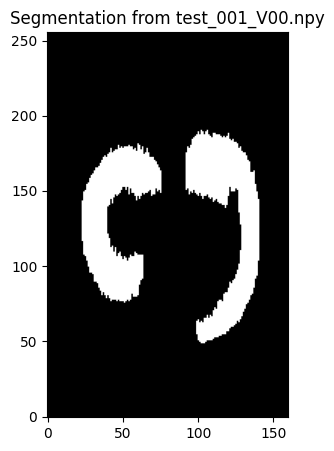

Segmentation shape: (200, 256, 160), unique labels: [0 1]


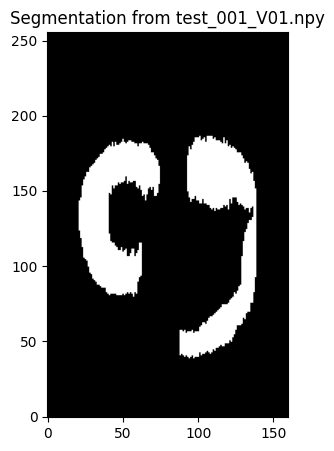

Segmentation shape: (200, 256, 160), unique labels: [0 1]


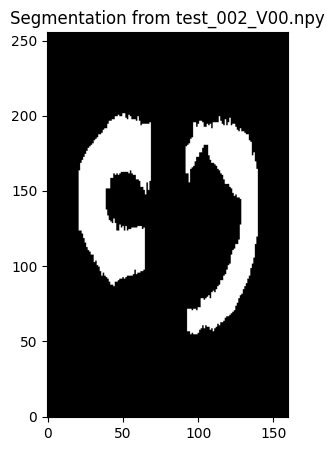

In [13]:
# cycle through a few segmentations and visualise (collapsed in y direction)
for seg_path in test_seg_paths[:3]:
    seg = np.load(seg_path)

    seg = seg[..., -1]  # take meniscus label
    seg = crop_im(seg)
    print(f'Segmentation shape: {seg.shape}, unique labels: {np.unique(seg)}')
    seg_collapsed = np.max(seg, axis=0)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(seg_collapsed, cmap='gray', origin='lower')
    plt.title(f'Segmentation from {os.path.basename(seg_path)}')
    plt.show()

In [14]:
# now cycle through and check for multiple connected components in meniscus label
for seg_path in test_seg_paths:
    seg = np.load(seg_path)
    meniscus_mask = seg[..., -1]  # meniscus label
    meniscus_mask = crop_im(meniscus_mask)

    # use cc3d to find connected components
    labeled_components, num_components = cc3d.connected_components(meniscus_mask, connectivity=26, return_N=True)
    if num_components > 2:
        print(f'Multiple connected components ({num_components}) found in meniscus label of {os.path.basename(seg_path)}')

Multiple connected components (3) found in meniscus label of test_003_V01.npy
Multiple connected components (3) found in meniscus label of test_006_V01.npy


## NOTES:
Only two of the test masks have more than 2 components. Could deal with these separately, while for the others, can just separate by looking at length of component in anterior-posterior dir.

### Let's go through and deal with components based on Centre of Mass 

Segmentation shape: (200, 256, 160), unique labels: [0 1]
Number of connected components: 2
Component 1: Centre of mass (z,x): (44.19, 136.06)
Component 2: Centre of mass (z,x): (120.43, 136.01)
Label 1 length: 106, Label 2 length: 142


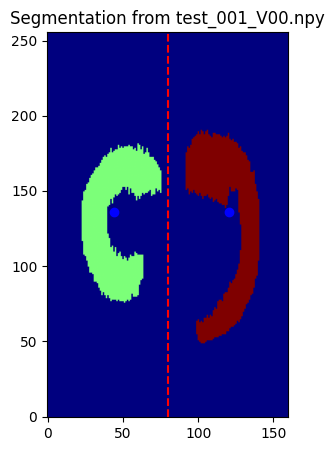

Segmentation shape: (200, 256, 160), unique labels: [0 1]
Number of connected components: 2
Component 1: Centre of mass (z,x): (43.18, 139.13)
Component 2: Centre of mass (z,x): (117.60, 124.02)
Label 1 length: 105, Label 2 length: 148


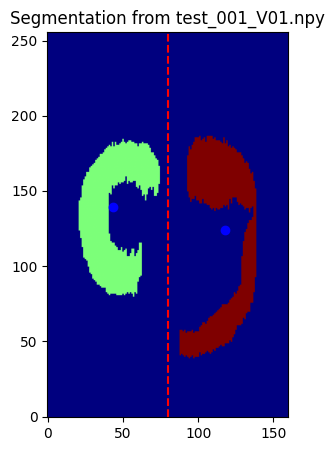

Segmentation shape: (200, 256, 160), unique labels: [0 1]
Number of connected components: 2
Component 1: Centre of mass (z,x): (43.41, 153.04)
Component 2: Centre of mass (z,x): (122.54, 141.61)
Label 1 length: 115, Label 2 length: 145


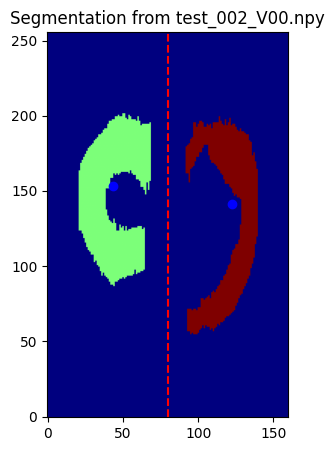

Segmentation shape: (200, 256, 160), unique labels: [0 1]
Number of connected components: 2
Component 1: Centre of mass (z,x): (42.81, 137.70)
Component 2: Centre of mass (z,x): (124.16, 133.01)
Label 1 length: 116, Label 2 length: 148


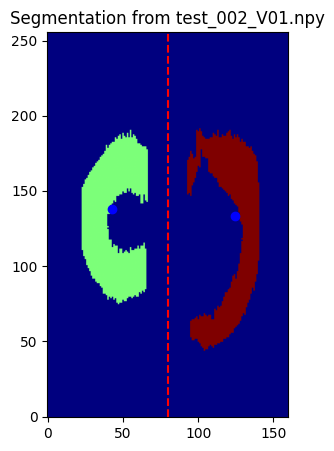

Segmentation shape: (200, 256, 160), unique labels: [0 1]
Number of connected components: 2
Component 1: Centre of mass (z,x): (42.28, 137.60)
Component 2: Centre of mass (z,x): (119.82, 143.38)
Label 1 length: 147, Label 2 length: 97


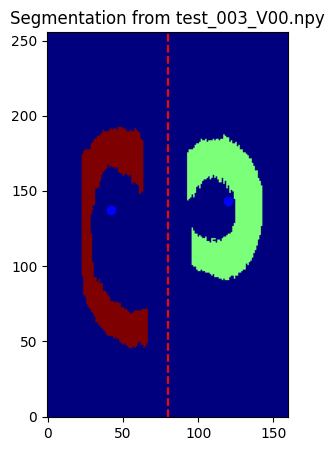

In [28]:
# Again, go through and visualise the test masks (collapsed in y direction)
for seg_path in test_seg_paths[:5]:
    seg = np.load(seg_path)

    seg = seg[..., -1]  # take meniscus label
    seg = crop_im(seg)
    print(f'Segmentation shape: {seg.shape}, unique labels: {np.unique(seg)}')
    
    # use cc3d to find connected components
    labeled_components, num_components = cc3d.connected_components(seg, connectivity=26, return_N=True)
    print(f'Number of connected components: {num_components}')

    # calculate centre of mass for each component in x,z plane
    for i in range(1, num_components + 1):
        component_mask = (labeled_components == i)
        com = np.array(np.nonzero(component_mask)).mean(axis=1)
        print(f'Component {i}: Centre of mass (z,x): ({com[2]:.2f}, {com[1]:.2f})')

    # group all components either side of sagittal midline into left/right meniscus
    label_1 = np.zeros_like(seg)
    label_2 = np.zeros_like(seg)
    midline = seg.shape[2] // 2

    for i in range(1, num_components + 1):
        component_mask = (labeled_components == i)
        com = np.array(np.nonzero(component_mask)).mean(axis=1)
        if com[2] < midline:
            label_1[component_mask] = 1  # left meniscus
        else:
            label_2[component_mask] = 1  # right meniscus

    # now decide which label is medial/lateral based on anterior-posterior length (medial is longer)
    length_1 = np.sum(np.any(label_1, axis=(0, 2)))
    length_2 = np.sum(np.any(label_2, axis=(0, 2)))

    medial, lateral = (label_1, label_2) if length_1 > length_2 else (label_2, label_1)

    multi_class_seg = np.zeros_like(seg)
    multi_class_seg[lateral == 1] = 1  # lateral meniscus
    multi_class_seg[medial == 1] = 2   # medial meniscus

    print(f'Label 1 length: {length_1}, Label 2 length: {length_2}')

    seg_collapsed = np.max(multi_class_seg, axis=0)

    plt.figure(figsize=(10, 5))
    plt.imshow(seg_collapsed, cmap='jet', origin='lower')

    # add a line splitting image in half sagittally
    plt.axvline(x=midline, color='r', linestyle='--')

    # add component centres of mass
    for i in range(1, num_components + 1):
        component_mask = (labeled_components == i)
        com = np.array(np.nonzero(component_mask)).mean(axis=1)
        plt.plot(com[2], com[1], 'bo')  # (x,z) for plotting

    plt.title(f'Segmentation from {os.path.basename(seg_path)}')
    plt.show()

## only spacing set for metadata - 0.365, 0.365, 0.7

## Loop through and resave in .nii.gz format for nnUNet

In [33]:
# new dataset folder to copy to
dst_folder = '../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/labelsMulticlassTs'
os.makedirs(dst_folder, exist_ok=True)

spacing = (0.365, 0.365, 0.70)

for i, seg_path in enumerate(tqdm(test_seg_paths)):
    seg = np.load(seg_path)

    seg = seg[..., -1]  # take meniscus label
    seg = crop_im(seg)
    
    # use cc3d to find connected components
    labeled_components, num_components = cc3d.connected_components(seg, connectivity=26, return_N=True)

    # group all components either side of sagittal midline into left/right meniscus
    label_1 = np.zeros_like(seg)
    label_2 = np.zeros_like(seg)
    midline = seg.shape[2] // 2

    for j in range(1, num_components + 1):
        component_mask = (labeled_components == j)
        com = np.array(np.nonzero(component_mask)).mean(axis=1)
        if com[2] < midline:
            label_1[component_mask] = 1  # left meniscus
        else:
            label_2[component_mask] = 1  # right meniscus

    # now decide which label is medial/lateral based on anterior-posterior length (medial is longer)
    length_1 = np.sum(np.any(label_1, axis=(0, 2)))
    length_2 = np.sum(np.any(label_2, axis=(0, 2)))

    medial, lateral = (label_1, label_2) if length_1 > length_2 else (label_2, label_1)

    multi_class_seg = np.zeros_like(seg)
    multi_class_seg[lateral == 1] = 1  # lateral meniscus
    multi_class_seg[medial == 1] = 2   # medial meniscus

    # Reorder dimensions
    reordered_mask = np.moveaxis(multi_class_seg, -1, 0)
    
    # Turn into sitk image
    sitk_mask = sitk.GetImageFromArray(reordered_mask)
    
    # Set spacing
    sitk_mask.SetSpacing(spacing)
    
    # Save mask
    sitk.WriteImage(sitk_mask, os.path.join(dst_folder, f'IWOAI_{str(i+1).zfill(3)}.nii.gz'))

100%|██████████| 28/28 [00:03<00:00,  7.16it/s]


## Do this again, but without cropping, reordering etc... Just save as npy for IWOAI format

In [6]:
# new dataset folder to copy to
dst_folder = '../data/IWOAI/ground-truth-multiclass'
os.makedirs(dst_folder, exist_ok=True)

for seg_path in tqdm(test_seg_paths):
    seg = np.load(seg_path)

    seg = seg[..., -1]  # take meniscus label
    
    # use cc3d to find connected components
    labeled_components, num_components = cc3d.connected_components(seg, connectivity=26, return_N=True)

    # group all components either side of sagittal midline into left/right meniscus
    label_1 = np.zeros_like(seg)
    label_2 = np.zeros_like(seg)
    midline = seg.shape[2] // 2

    for j in range(1, num_components + 1):
        component_mask = (labeled_components == j)
        com = np.array(np.nonzero(component_mask)).mean(axis=1)
        if com[2] < midline:
            label_1[component_mask] = 1  # left meniscus
        else:
            label_2[component_mask] = 1  # right meniscus

    # now decide which label is medial/lateral based on anterior-posterior length (medial is longer)
    length_1 = np.sum(np.any(label_1, axis=(0, 2)))
    length_2 = np.sum(np.any(label_2, axis=(0, 2)))

    medial, lateral = (label_1, label_2) if length_1 > length_2 else (label_2, label_1)

    multi_class_seg = np.zeros_like(seg)
    multi_class_seg[lateral == 1] = 1  # lateral meniscus
    multi_class_seg[medial == 1] = 2   # medial meniscus

    # Save mask as numpy array
    np.save(os.path.join(dst_folder, os.path.basename(seg_path)), multi_class_seg)

100%|██████████| 28/28 [00:53<00:00,  1.92s/it]


# check a few image/mask pairs to double check

Image shape: (160, 200, 256), Mask shape: (160, 200, 256), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 74


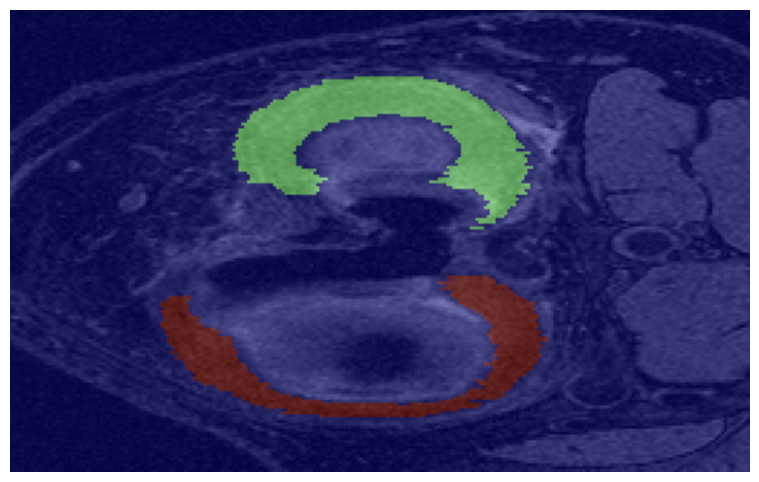

Image shape: (160, 200, 256), Mask shape: (160, 200, 256), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 83


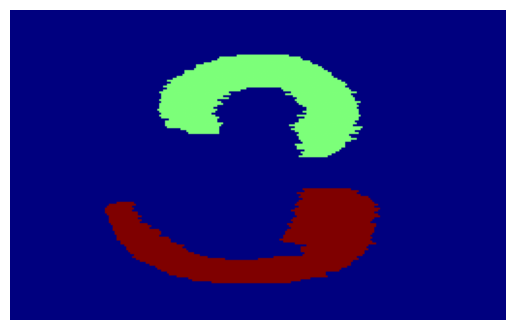

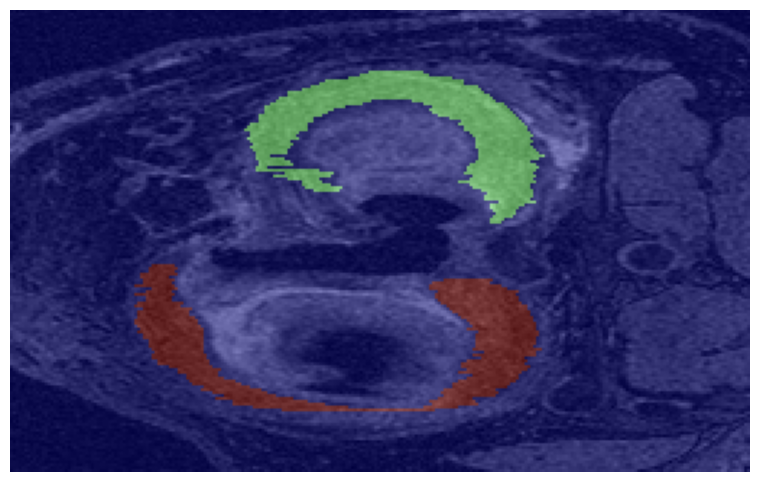

Image shape: (160, 200, 256), Mask shape: (160, 200, 256), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 99


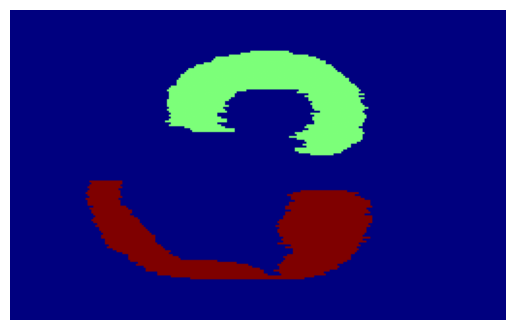

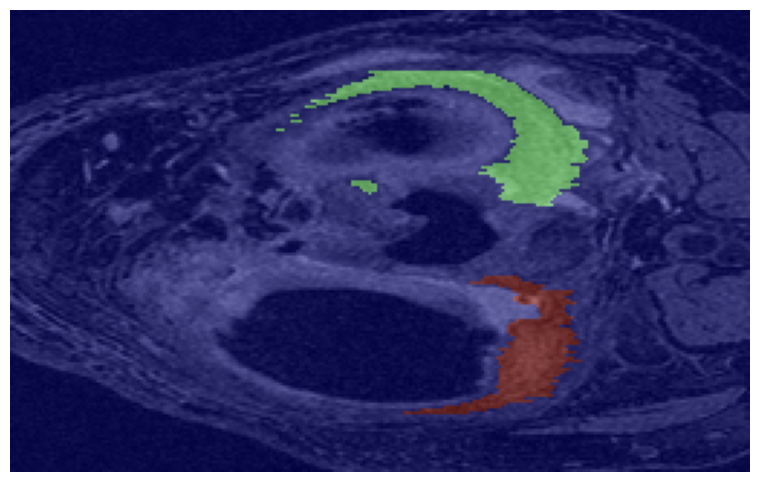

Image shape: (160, 200, 256), Mask shape: (160, 200, 256), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 71


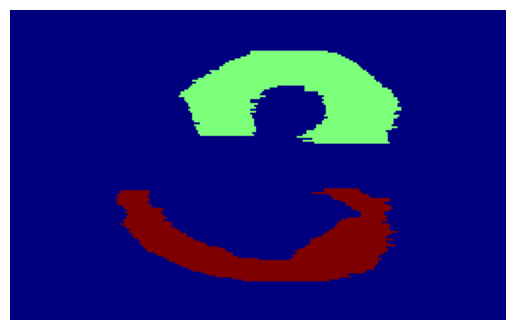

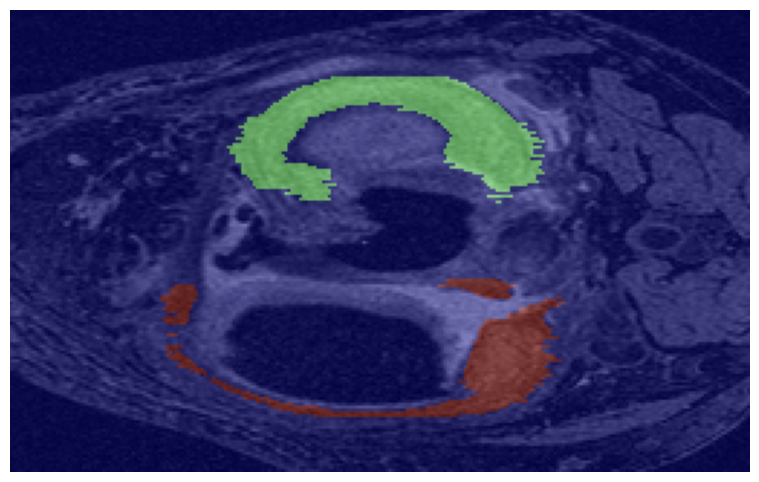

Image shape: (160, 200, 256), Mask shape: (160, 200, 256), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 100


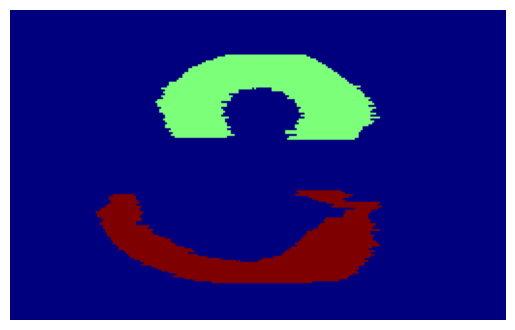

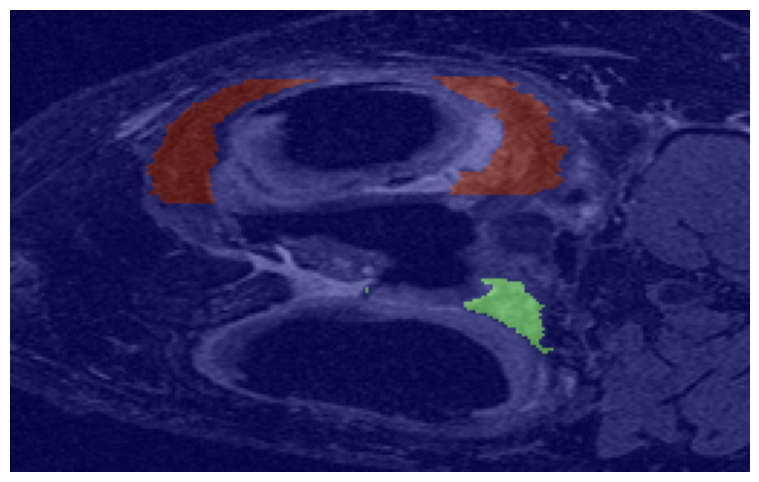

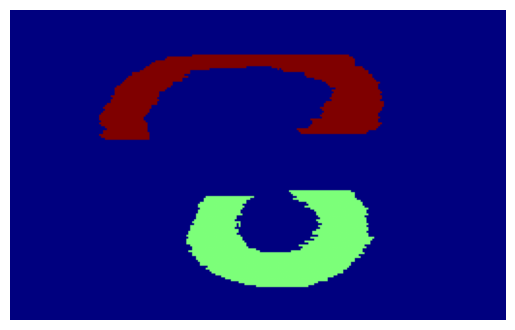

In [40]:
# pick a few image/mask pairs to double check
im_paths = sorted(glob.glob('../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/imagesTs/*.nii.gz'))
mask_paths = sorted(glob.glob('../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/labelsMulticlassTs/*.nii.gz'))

for im_path, mask_path in zip(im_paths[:5], mask_paths[:5]):
    im = sitk.ReadImage(im_path)
    mask = sitk.ReadImage(mask_path)
    
    im_array = sitk.GetArrayFromImage(im)
    mask_array = sitk.GetArrayFromImage(mask)

    print(f'Image shape: {im_array.shape}, Mask shape: {mask_array.shape}, Unique mask labels: {np.unique(mask_array)}')

    # midrange y slice of nonzero mask
    nonzero_mask = np.nonzero(mask_array)
    midrange_y = (nonzero_mask[1].min() + nonzero_mask[1].max()) // 2
    print(f'Midrange y slice of nonzero mask: {midrange_y}')
    
    slice_idx = midrange_y
    
    plt.figure(figsize=(12, 6))
    plt.imshow(im_array[:, slice_idx, :], cmap='gray')
    plt.imshow(mask_array[:, slice_idx, :], cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

    # now collapse to 2D and check
    plt.imshow(np.max(mask_array, axis=1), cmap='jet')
    plt.axis('off')

Image shape: (384, 384, 160), Mask shape: (384, 384, 160), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 194


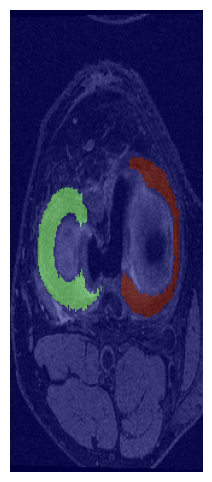

Image shape: (384, 384, 160), Mask shape: (384, 384, 160), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 203


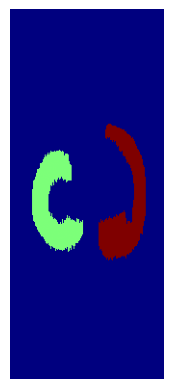

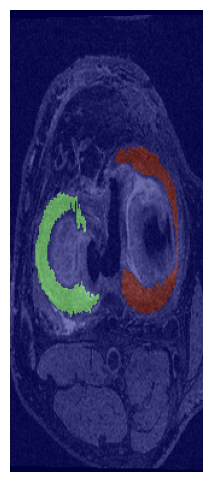

Image shape: (384, 384, 160), Mask shape: (384, 384, 160), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 219


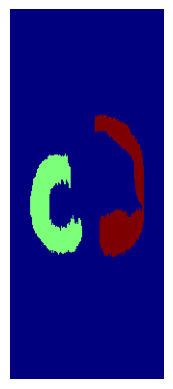

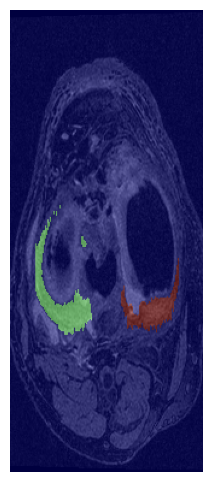

Image shape: (384, 384, 160), Mask shape: (384, 384, 160), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 191


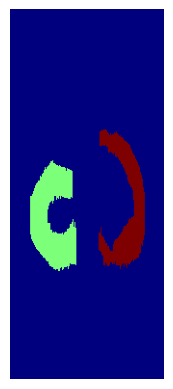

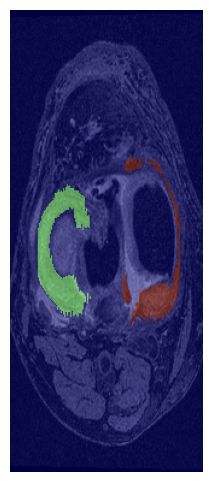

Image shape: (384, 384, 160), Mask shape: (384, 384, 160), Unique mask labels: [0 1 2]
Midrange y slice of nonzero mask: 220


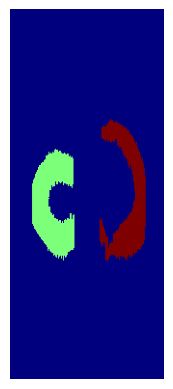

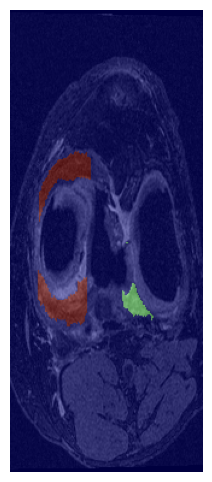

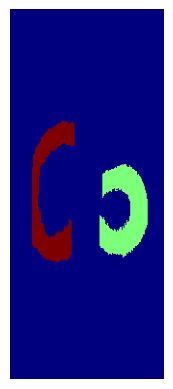

In [9]:
# pick a few image/mask pairs to double check
im_paths = sorted(glob.glob('../data/IWOAI/test/*.im'))
mask_paths = sorted(glob.glob('../data/IWOAI/ground-truth-multiclass/*.npy'))

for im_path, mask_path in zip(im_paths[:5], mask_paths[:5]):
    with h5py.File(im_path, 'r') as f:
        im_array = f['data'][:]
    mask_array = np.load(mask_path)

    print(f'Image shape: {im_array.shape}, Mask shape: {mask_array.shape}, Unique mask labels: {np.unique(mask_array)}')

    # midrange y slice of nonzero mask
    nonzero_mask = np.nonzero(mask_array)
    midrange_y = (nonzero_mask[0].min() + nonzero_mask[0].max()) // 2
    print(f'Midrange y slice of nonzero mask: {midrange_y}')
    
    slice_idx = midrange_y
    
    plt.figure(figsize=(12, 6))
    plt.imshow(im_array[slice_idx, ...], cmap='gray')
    plt.imshow(mask_array[slice_idx, ...], cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

    # now collapse to 2D and check
    plt.imshow(np.max(mask_array, axis=0), cmap='jet')
    plt.axis('off')